# AIMS KTT 2026: Dynamic Pricing Simulation & ROI Analysis
**Project:** Perishable Goods Optimization (T1.3)  
**Lead Architect:** Jerome Teyi  

## Executive Summary
This notebook serves as the **Technical Proof of Concept (PoC)** for the KTT Dynamic Pricing Engine. It simulates a **7-day market cycle** (hour-by-hour) to validate the core mathematical model against a traditional **Fixed Cost-Plus baseline**.

### Key Simulation Parameters:
* **Currency:** Rwandan Franc (RWF).
* **Model:** Non-linear decay ($1.5$ exponent) with a **1.18 Margin Floor**.
* **Goal:** Demonstrate simultaneous **Revenue Growth** and **Waste Minimization**.

In [68]:
from __future__ import annotations

import math
import sys
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Project root resolution
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists() and (PROJECT_ROOT.parent / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"
stock_path = DATA_DIR / "stock.csv"
competitor_path = DATA_DIR / "competitor_prices.csv"
sales_history_path = DATA_DIR / "sales_history.csv"

missing_paths = [p for p in [stock_path, competitor_path, sales_history_path] if not p.exists()]
if missing_paths:
    raise FileNotFoundError(
        "Missing required input files:\n" + "\n".join(str(p) for p in missing_paths)
    )

# Import the pricing logic from the engine
try:
    from src.math_engine import suggest_price, compute_freshness_factor, expected_demand
except ImportError:
    try:
        from math_engine import suggest_price, compute_freshness_factor, expected_demand
    except ImportError:
        # Compatibility fallback for engines that expose older function names
        try:
            from src.math_engine import suggest_price, freshness_factor as compute_freshness_factor, demand_formula as expected_demand
        except ImportError:
            from math_engine import suggest_price, freshness_factor as compute_freshness_factor, demand_formula as expected_demand

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True

print("Notebook setup completed successfully.")

Notebook setup completed successfully.


In [69]:
stock_raw = pd.read_csv(stock_path)
competitor_raw = pd.read_csv(competitor_path)
sales_history_raw = pd.read_csv(sales_history_path)

print(f"stock.csv shape: {stock_raw.shape}")
print(f"competitor_prices.csv shape: {competitor_raw.shape}")
print(f"sales_history.csv shape: {sales_history_raw.shape}")

display(stock_raw.head(3))
display(competitor_raw.head(3))
display(sales_history_raw.head(3))

stock.csv shape: (120, 7)
competitor_prices.csv shape: (4608, 4)
sales_history.csv shape: (384, 10)


,sku_id,product,purchased_at,quantity,unit_cost_rwf,shelf_life_hours,supplier
0,SKU0097,banana,2026-04-17 17:27:00,49,329,120,SunBelt Produce
1,SKU0116,banana,2026-04-17 18:23:00,17,342,120,Tropic Harvest
2,SKU0112,banana,2026-04-17 20:18:00,35,331,120,SunBelt Produce


,timestamp,product,stall_id,competitor_price_rwf
0,2026-04-20 08:30:00,banana,stall_01,566
1,2026-04-20 08:30:00,banana,stall_02,522
2,2026-04-20 08:30:00,banana,stall_03,515


,timestamp,product,offered_price_rwf,competitor_mean_price_rwf,p_ref_rwf,q0,alpha,freshness_factor,expected_demand,units_sold
0,2026-04-20 08:30:00,banana,565,578.75,550,15.0,1.3,0.8461,12.2492,20
1,2026-04-20 08:30:00,milk,821,823.33,800,12.0,1.8,0.0500,0.5723,0
2,2026-04-20 08:30:00,tilapia,1197,1243.33,1200,9.0,2.0,0.0500,0.4523,1


## Helper functions

These helpers:
- normalize column names
- prepare kilogram conversion
- build demand profiles from `sales_history.csv`

In [70]:
CURRENCY_CODE = "RWF"

DEFAULT_ALPHA = 1.25
DEFAULT_MIN_PRICE_MULTIPLIER = 0.85
DEFAULT_MAX_PRICE_MULTIPLIER = 2.20

DEFAULT_UNIT_WEIGHT_KG = {
    "tomato": 0.15,
    "tomate": 0.15,
    "banana": 0.12,
    "banane": 0.12,
    "milk": 1.00,
    "lait": 1.00,
    "tilapia": 1.00,
}


@dataclass
class DemandProfile:
    q0: float
    alpha: float
    p_ref: float


@dataclass
class StrategyRun:
    name: str
    total_revenue: float
    total_profit: float
    total_waste_kg: float
    volume_sold_rate_pct: float
    trace: pd.DataFrame


def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    renamed = {
        col: (
            str(col)
            .strip()
            .lower()
            .replace(" ", "_")
            .replace("-", "_")
            .replace("/", "_")
            .replace("(", "")
            .replace(")", "")
        )
        for col in df.columns
    }
    return df.rename(columns=renamed).copy()


def pick_first_existing(columns: Iterable[str], candidates: Iterable[str]) -> Optional[str]:
    column_set = set(columns)
    for candidate in candidates:
        if candidate in column_set:
            return candidate
    return None


def resolve_currency_column(columns: Iterable[str], candidates: Iterable[str], label: str) -> str:
    found = pick_first_existing(columns, candidates)
    if found is None:
        raise ValueError(f"Could not find a valid {label} column. Tried: {list(candidates)}")
    return found


def match_unit_weight(product_name: str) -> float:
    normalized = str(product_name).strip().lower()
    for key, value in DEFAULT_UNIT_WEIGHT_KG.items():
        if key in normalized:
            return float(value)
    return 1.0


def load_stock(stock_path: Path) -> pd.DataFrame:
    stock = normalize_columns(pd.read_csv(stock_path))

    required = {
        "sku_id",
        "product",
        "purchased_at",
        "quantity",
        "shelf_life_hours",
    }
    missing = required - set(stock.columns)
    if missing:
        raise ValueError(f"stock.csv is missing required columns: {sorted(missing)}")

    unit_cost_col = resolve_currency_column(
        stock.columns,
        ["unit_cost_rwf", "unit_cost_xaf", "unit_cost", "cost_rwf", "cost_xaf", "cost"],
        label="unit cost",
    )
    stock = stock.rename(columns={unit_cost_col: "unit_cost"}).copy()

    stock["purchased_at"] = pd.to_datetime(stock["purchased_at"], errors="coerce")
    if stock["purchased_at"].isna().any():
        raise ValueError("stock.csv contains invalid timestamps in 'purchased_at'.")

    for col in ["quantity", "unit_cost", "shelf_life_hours"]:
        stock[col] = pd.to_numeric(stock[col], errors="coerce")
        if stock[col].isna().any():
            raise ValueError(f"stock.csv contains invalid numeric values in '{col}'.")

    if "unit_weight_kg" in stock.columns:
        stock["unit_weight_kg"] = pd.to_numeric(stock["unit_weight_kg"], errors="coerce")
    else:
        stock["unit_weight_kg"] = np.nan

    inferred_weights = stock["product"].map(match_unit_weight).astype(float)
    stock["unit_weight_kg"] = stock["unit_weight_kg"].fillna(inferred_weights)

    if (stock["unit_weight_kg"] <= 0).any():
        raise ValueError("All unit weights must be strictly positive.")

    stock = stock.sort_values(["product", "purchased_at", "sku_id"]).reset_index(drop=True)
    return stock

In [71]:
class CompetitorPriceBook:
    def __init__(self, competitor_df: pd.DataFrame) -> None:
        self.df = competitor_df.copy()

        self.timestamp_col = pick_first_existing(
            self.df.columns,
            ["timestamp", "datetime", "date_time", "recorded_at", "ds", "hour"],
        )
        self.product_col = pick_first_existing(self.df.columns, ["product", "sku_id", "item"])
        self.price_col = resolve_currency_column(
            self.df.columns,
            [
                "competitor_price_rwf",
                "price_rwf",
                "selling_price_rwf",
                "market_price_rwf",
                "competitor_price_xaf",
                "price_xaf",
                "selling_price_xaf",
                "market_price_xaf",
                "price",
            ],
            label="competitor price",
        )

        self.df[self.price_col] = pd.to_numeric(self.df[self.price_col], errors="coerce")
        self.df = self.df.dropna(subset=[self.price_col]).copy()

        if self.timestamp_col is not None:
            self.df[self.timestamp_col] = pd.to_datetime(self.df[self.timestamp_col], errors="coerce")
            if self.df[self.timestamp_col].notna().any():
                self.df["hour_of_day"] = self.df[self.timestamp_col].dt.hour.astype(int)
            else:
                self.timestamp_col = None
                self.df["hour_of_day"] = 0
        else:
            self.df["hour_of_day"] = 0

        if self.product_col is not None:
            self.df[self.product_col] = self.df[self.product_col].astype(str)

        self.product_hourly_mean: Dict[tuple[str, int], float] = {}
        self.product_mean: Dict[str, float] = {}
        self.global_hourly_mean: Dict[int, float] = {}
        self.global_mean: float = float(self.df[self.price_col].mean()) if not self.df.empty else 0.0

        if self.product_col is not None:
            grouped = (
                self.df.groupby([self.product_col, "hour_of_day"], as_index=False)[self.price_col]
                .mean()
            )
            self.product_hourly_mean = {
                (str(row[self.product_col]), int(row["hour_of_day"])): float(row[self.price_col])
                for _, row in grouped.iterrows()
            }

            grouped_product = self.df.groupby(self.product_col, as_index=False)[self.price_col].mean()
            self.product_mean = {
                str(row[self.product_col]): float(row[self.price_col])
                for _, row in grouped_product.iterrows()
            }

        grouped_global = self.df.groupby("hour_of_day", as_index=False)[self.price_col].mean()
        self.global_hourly_mean = {
            int(row["hour_of_day"]): float(row[self.price_col])
            for _, row in grouped_global.iterrows()
        }

    def get_prices(self, product_key: str, hour_of_day: int, fallback_cost: float) -> List[float]:
        hour_of_day = int(hour_of_day) % 24
        product_key = str(product_key)

        prices: List[float] = []

        if self.product_hourly_mean:
            value = self.product_hourly_mean.get((product_key, hour_of_day))
            if value is not None:
                prices.append(value)

        if not prices and self.product_mean:
            value = self.product_mean.get(product_key)
            if value is not None:
                prices.append(value)

        if not prices:
            value = self.global_hourly_mean.get(hour_of_day)
            if value is not None:
                prices.append(value)

        if not prices and self.global_mean > 0:
            prices.append(self.global_mean)

        if not prices:
            prices.append(max(1.0, float(fallback_cost) * 1.20))

        return [float(p) for p in prices if float(p) > 0]


def load_competitor_pricebook(competitor_path: Path) -> CompetitorPriceBook:
    df = normalize_columns(pd.read_csv(competitor_path))
    return CompetitorPriceBook(df)

In [72]:
def derive_profiles_from_direct_parameters(history: pd.DataFrame) -> Dict[str, DemandProfile]:
    key_col = pick_first_existing(history.columns, ["product", "sku_id", "item"])
    if key_col is None:
        return {}

    q0_col = pick_first_existing(history.columns, ["q0", "base_demand", "hourly_base_demand"])
    alpha_col = pick_first_existing(history.columns, ["alpha", "price_elasticity", "elasticity_alpha"])
    pref_col = pick_first_existing(
        history.columns,
        [
            "p_ref",
            "reference_price_rwf",
            "ref_price_rwf",
            "price_ref_rwf",
            "reference_price_xaf",
            "ref_price_xaf",
            "price_ref_xaf",
        ],
    )

    if not all([q0_col, alpha_col, pref_col]):
        return {}

    profiles: Dict[str, DemandProfile] = {}
    grouped = history.groupby(key_col, as_index=False)[[q0_col, alpha_col, pref_col]].mean()
    for _, row in grouped.iterrows():
        profiles[str(row[key_col])] = DemandProfile(
            q0=max(0.1, float(row[q0_col])),
            alpha=max(0.01, float(row[alpha_col])),
            p_ref=max(1.0, float(row[pref_col])),
        )
    return profiles


def derive_profiles_from_transactions(history: pd.DataFrame) -> Dict[str, DemandProfile]:
    key_col = pick_first_existing(history.columns, ["product", "sku_id", "item"])
    qty_col = pick_first_existing(
        history.columns,
        ["units_sold", "quantity_sold", "qty_sold", "sales_qty", "sold_units", "quantity"],
    )
    price_col = pick_first_existing(
        history.columns,
        [
            "sale_price_rwf",
            "selling_price_rwf",
            "price_rwf",
            "unit_price_rwf",
            "sale_price_xaf",
            "selling_price_xaf",
            "price_xaf",
            "unit_price_xaf",
            "price",
        ],
    )

    if key_col is None or qty_col is None or price_col is None:
        return {}

    work = history.copy()
    work[qty_col] = pd.to_numeric(work[qty_col], errors="coerce")
    work[price_col] = pd.to_numeric(work[price_col], errors="coerce")
    work = work.dropna(subset=[key_col, qty_col, price_col])
    work = work[(work[qty_col] >= 0) & (work[price_col] > 0)]
    if work.empty:
        return {}

    profiles: Dict[str, DemandProfile] = {}
    for key, group in work.groupby(key_col):
        group = group.copy()
        p_ref = float(group[price_col].median())
        if not math.isfinite(p_ref) or p_ref <= 0:
            continue

        near_ref_mask = (group[price_col] - p_ref).abs() / p_ref <= 0.10
        q0_source = group[near_ref_mask] if near_ref_mask.any() else group
        q0 = float(max(0.1, q0_source[qty_col].mean()))

        x = (group[price_col].to_numpy(dtype=float) - p_ref) / p_ref
        y = np.log(group[qty_col].to_numpy(dtype=float) + 1e-6)

        if len(np.unique(x)) >= 2:
            slope, _ = np.polyfit(x, y, deg=1)
            alpha = float(max(0.01, -slope))
        else:
            alpha = DEFAULT_ALPHA

        profiles[str(key)] = DemandProfile(q0=q0, alpha=alpha, p_ref=p_ref)

    return profiles


def build_demand_profiles(history_path: Path, stock: pd.DataFrame) -> Dict[str, DemandProfile]:
    history = normalize_columns(pd.read_csv(history_path))

    direct_profiles = derive_profiles_from_direct_parameters(history)
    if direct_profiles:
        return direct_profiles

    inferred_profiles = derive_profiles_from_transactions(history)
    if inferred_profiles:
        return inferred_profiles

    fallback_profiles: Dict[str, DemandProfile] = {}
    grouped = stock.groupby("product", as_index=False).agg(
        avg_quantity=("quantity", "mean"),
        avg_cost=("unit_cost", "mean"),
    )
    for _, row in grouped.iterrows():
        fallback_profiles[str(row["product"])] = DemandProfile(
            q0=max(1.0, float(row["avg_quantity"]) * 0.10),
            alpha=DEFAULT_ALPHA,
            p_ref=max(1.0, float(row["avg_cost"]) * 1.20),
        )
    return fallback_profiles


def resolve_dynamic_price(raw_result: Any, fallback_price: float) -> float:
    if isinstance(raw_result, (int, float, np.integer, np.floating)):
        return float(raw_result)

    if isinstance(raw_result, dict):
        for key in [
            "optimal_price_rwf",
            "price_rwf",
            "recommended_price_rwf",
            "optimal_price_xaf",
            "price_xaf",
            "recommended_price_xaf",
            "optimal_price",
            "price",
            "recommended_price",
        ]:
            if key in raw_result:
                return float(raw_result[key])

    return float(fallback_price)

## Simulation engine

The simulation compares two strategies over **7 days**, hour by hour:

- **Baseline**: static price = **Cost + 20%**
- **Dynamic Agent**: price proposed by `suggest_price(...)`

The notebook reports:
- total revenue
- total profit
- total waste in **kg**
- volume sold rate in **% of total kilograms available**

In [73]:
def simulate_strategy(
    strategy_name: str,
    stock: pd.DataFrame,
    pricebook: CompetitorPriceBook,
    demand_profiles: Dict[str, DemandProfile],
    hours: int = 7 * 24,
    stochastic: bool = False,
    seed: int = 42,
    trace_sku_id: Optional[str] = None,
) -> StrategyRun:
    rng = np.random.default_rng(seed)

    working = stock.copy().reset_index(drop=True)

    sku_ids = working["sku_id"].astype(str).to_numpy()
    products = working["product"].astype(str).to_numpy()
    purchased_at = pd.to_datetime(working["purchased_at"])
    purchase_hour = purchased_at.dt.hour.to_numpy(dtype=int)

    initial_qty = working["quantity"].to_numpy(dtype=float)
    remaining_qty = initial_qty.copy()

    unit_cost = working["unit_cost"].to_numpy(dtype=float)
    shelf_life_hours = working["shelf_life_hours"].to_numpy(dtype=float)
    unit_weight_kg = working["unit_weight_kg"].to_numpy(dtype=float)

    initial_inventory_kg = initial_qty * unit_weight_kg

    revenue_amount = np.zeros(len(working), dtype=float)
    cost_amount = np.zeros(len(working), dtype=float)
    waste_kg = np.zeros(len(working), dtype=float)
    sold_kg = np.zeros(len(working), dtype=float)

    expired = np.zeros(len(working), dtype=bool)

    profile_keys = []
    for _, row in working.iterrows():
        if str(row["sku_id"]) in demand_profiles:
            profile_keys.append(str(row["sku_id"]))
        elif str(row["product"]) in demand_profiles:
            profile_keys.append(str(row["product"]))
        else:
            profile_keys.append(None)

    q0 = np.array(
        [
            demand_profiles[key].q0 if key is not None else max(1.0, float(initial_qty[i]) * 0.10)
            for i, key in enumerate(profile_keys)
        ],
        dtype=float,
    )
    alpha = np.array(
        [
            demand_profiles[key].alpha if key is not None else DEFAULT_ALPHA
            for key in profile_keys
        ],
        dtype=float,
    )
    p_ref = np.array(
        [
            demand_profiles[key].p_ref if key is not None else max(1.0, float(unit_cost[i]) * 1.20)
            for i, key in enumerate(profile_keys)
        ],
        dtype=float,
    )

    trace_records: List[Dict[str, Any]] = []
    trace_idx = None
    if trace_sku_id is not None:
        matches = np.where(sku_ids == str(trace_sku_id))[0]
        if len(matches) > 0:
            trace_idx = int(matches[0])

    for hour_idx in range(hours):
        age_hours = float(hour_idx)
        active_mask = (~expired) & (remaining_qty > 0)

        if active_mask.any():
            just_expired = active_mask & (age_hours > shelf_life_hours)
            if just_expired.any():
                waste_kg[just_expired] += remaining_qty[just_expired] * unit_weight_kg[just_expired]
                remaining_qty[just_expired] = 0.0
                expired[just_expired] = True

        active_idx = np.where((~expired) & (remaining_qty > 0))[0]

        raw_price_map: Dict[int, float] = {}
        rounded_price_map: Dict[int, int] = {}
        freshness_map: Dict[int, float] = {}
        units_sold_map: Dict[int, float] = {}

        for idx in active_idx:
            current_hour_of_day = int((purchase_hour[idx] + hour_idx) % 24)
            freshness = float(compute_freshness_factor(age_hours, float(shelf_life_hours[idx])))
            freshness_map[idx] = freshness

            baseline_price = max(1.0, float(unit_cost[idx]) * 1.20)

            if strategy_name == "Baseline":
                raw_price = float(baseline_price)
            else:
                competitor_prices = pricebook.get_prices(
                    product_key=str(products[idx]),
                    hour_of_day=current_hour_of_day,
                    fallback_cost=float(unit_cost[idx]),
                )
                pricing_input = {
                    "sku_id": sku_ids[idx],
                    "product": products[idx],
                    "purchased_at": purchased_at.iloc[idx],
                    "quantity": float(initial_qty[idx]),
                    "remaining_qty": float(remaining_qty[idx]),
                    "unit_cost": float(unit_cost[idx]),
                    "unit_cost_rwf": float(unit_cost[idx]),
                    "unit_cost_xaf": float(unit_cost[idx]),
                    "shelf_life_hours": float(shelf_life_hours[idx]),
                    "age_hours": age_hours,
                    "freshness_factor": freshness,
                    "q0": float(q0[idx]),
                    "alpha": float(alpha[idx]),
                    "p_ref": float(p_ref[idx]),
                    "p_ref_rwf": float(p_ref[idx]),
                    "p_ref_xaf": float(p_ref[idx]),
                    "competitor_reference_price": float(np.mean(competitor_prices)),
                    "competitor_reference_price_rwf": float(np.mean(competitor_prices)),
                    "competitor_reference_price_xaf": float(np.mean(competitor_prices)),
                }
                current_ts = purchased_at.iloc[idx] + pd.Timedelta(hours=hour_idx)
                raw_result = suggest_price(pricing_input, current_ts, competitor_prices)
                raw_price = resolve_dynamic_price(raw_result, fallback_price=baseline_price)

            lower_bound = max(0.0, float(unit_cost[idx]) * DEFAULT_MIN_PRICE_MULTIPLIER)
            upper_bound = max(lower_bound, float(unit_cost[idx]) * DEFAULT_MAX_PRICE_MULTIPLIER)
            raw_price = float(np.clip(raw_price, lower_bound, upper_bound))
            rounded_price = int(round(raw_price))

            expected_qty = float(
                expected_demand(
                    price=float(rounded_price),
                    q0=float(q0[idx]),
                    alpha=float(alpha[idx]),
                    p_ref=float(p_ref[idx]),
                    freshness_factor=freshness,
                )
            )

            capped_qty = max(0.0, min(expected_qty, float(remaining_qty[idx])))
            if stochastic:
                sold_units = float(min(rng.poisson(capped_qty), remaining_qty[idx]))
            else:
                sold_units = float(min(int(round(capped_qty)), remaining_qty[idx]))

            remaining_qty[idx] -= sold_units
            revenue_amount[idx] += float(rounded_price) * sold_units
            cost_amount[idx] += float(unit_cost[idx]) * sold_units
            sold_kg[idx] += sold_units * unit_weight_kg[idx]

            if remaining_qty[idx] <= 0:
                remaining_qty[idx] = 0.0

            raw_price_map[idx] = raw_price
            rounded_price_map[idx] = rounded_price
            units_sold_map[idx] = sold_units

        if trace_idx is not None:
            trace_records.append(
                {
                    "hour": hour_idx,
                    "age_hours": age_hours,
                    "freshness_factor": freshness_map.get(trace_idx, 0.0),
                    "raw_price": raw_price_map.get(trace_idx, np.nan),
                    "rounded_price": rounded_price_map.get(trace_idx, np.nan),
                    "units_sold": units_sold_map.get(trace_idx, 0.0),
                    "remaining_qty": remaining_qty[trace_idx],
                    "expired": bool(expired[trace_idx] or age_hours > float(shelf_life_hours[trace_idx])),
                }
            )

    total_revenue = float(revenue_amount.sum())
    total_profit = float((revenue_amount - cost_amount).sum())
    total_waste_kg = float(waste_kg.sum())
    total_initial_kg = float(initial_inventory_kg.sum())
    total_sold_kg = float(sold_kg.sum())
    volume_sold_rate_pct = 100.0 * total_sold_kg / total_initial_kg if total_initial_kg > 0 else 0.0

    trace_df = pd.DataFrame(trace_records)

    return StrategyRun(
        name=strategy_name,
        total_revenue=total_revenue,
        total_profit=total_profit,
        total_waste_kg=total_waste_kg,
        volume_sold_rate_pct=volume_sold_rate_pct,
        trace=trace_df,
    )

In [74]:
stock = load_stock(stock_path)
pricebook = load_competitor_pricebook(competitor_path)
demand_profiles = build_demand_profiles(sales_history_path, stock)

print(f"Currency used for reporting: {CURRENCY_CODE}")
print(f"Number of stock rows: {len(stock)}")
print(f"Number of demand profiles: {len(demand_profiles)}")
display(stock.head())

Currency used for reporting: RWF
Number of stock rows: 120
Number of demand profiles: 4


,sku_id,product,purchased_at,quantity,unit_cost,shelf_life_hours,supplier,unit_weight_kg
0,SKU0097,banana,2026-04-17 17:27:00,49,329,120,SunBelt Produce,0.12
1,SKU0116,banana,2026-04-17 18:23:00,17,342,120,Tropic Harvest,0.12
2,SKU0112,banana,2026-04-17 20:18:00,35,331,120,SunBelt Produce,0.12
3,SKU0101,banana,2026-04-17 23:35:00,54,333,120,Banana Brothers,0.12
4,SKU0115,banana,2026-04-18 10:16:00,19,366,120,Tropic Harvest,0.12


## Choose one SKU for the detailed price path

The notebook prioritizes **Tilapia** if it exists. Otherwise, it selects the first available SKU.

In [75]:
tilapia_mask = stock["product"].astype(str).str.lower().str.contains("tilapia", na=False)
if tilapia_mask.any():
    trace_sku_id = str(stock.loc[tilapia_mask, "sku_id"].iloc[0])
else:
    trace_sku_id = str(stock["sku_id"].iloc[0])

trace_product = stock.loc[stock["sku_id"].astype(str) == trace_sku_id, "product"].iloc[0]
trace_weight = stock.loc[stock["sku_id"].astype(str) == trace_sku_id, "unit_weight_kg"].iloc[0]

print(f"Trace SKU selected: {trace_sku_id}")
print(f"Trace product: {trace_product}")
print(f"Unit weight used for kg conversion: {trace_weight:.2f} kg")

Trace SKU selected: SKU0072
Trace product: tilapia
Unit weight used for kg conversion: 1.00 kg


## Run the 7-day simulation

The baseline uses a static cost-plus policy.  
The agent uses the dynamic price returned by `src.math_engine`.

In [76]:
HOURS = 7 * 24

baseline_run = simulate_strategy(
    strategy_name="Baseline",
    stock=stock,
    pricebook=pricebook,
    demand_profiles=demand_profiles,
    hours=HOURS,
    stochastic=False,
    seed=42,
    trace_sku_id=trace_sku_id,
)

dynamic_run = simulate_strategy(
    strategy_name="Dynamic",
    stock=stock,
    pricebook=pricebook,
    demand_profiles=demand_profiles,
    hours=HOURS,
    stochastic=False,
    seed=42,
    trace_sku_id=trace_sku_id,
)

comparison_df = pd.DataFrame(
    [
        {
            "Strategy": baseline_run.name,
            f"Total Revenue ({CURRENCY_CODE})": baseline_run.total_revenue,
            f"Total Profit ({CURRENCY_CODE})": baseline_run.total_profit,
            "Total Waste (kg)": baseline_run.total_waste_kg,
            "Volume Sold Rate (%)": baseline_run.volume_sold_rate_pct,
        },
        {
            "Strategy": dynamic_run.name,
            f"Total Revenue ({CURRENCY_CODE})": dynamic_run.total_revenue,
            f"Total Profit ({CURRENCY_CODE})": dynamic_run.total_profit,
            "Total Waste (kg)": dynamic_run.total_waste_kg,
            "Volume Sold Rate (%)": dynamic_run.volume_sold_rate_pct,
        },
    ]
)

display(
    comparison_df.style.format(
        {
            f"Total Revenue ({CURRENCY_CODE})": "{:,.2f}",
            f"Total Profit ({CURRENCY_CODE})": "{:,.2f}",
            "Total Waste (kg)": "{:,.2f}",
            "Volume Sold Rate (%)": "{:,.2f}",
        }
    )
)

,Strategy,Total Revenue (RWF),Total Profit (RWF),Total Waste (kg),Volume Sold Rate (%)
0,Baseline,"1,871,502.00","311,773.00",176.00,92.63
1,Dynamic,"2,275,626.00","1,061,670.00",954.00,60.05


## Visualization 1 — Price vs. Freshness over time for one SKU

This chart shows:
- the **baseline transaction price**
- the **dynamic raw price** with 2 decimals
- the **dynamic rounded proposal**
- the **freshness factor**

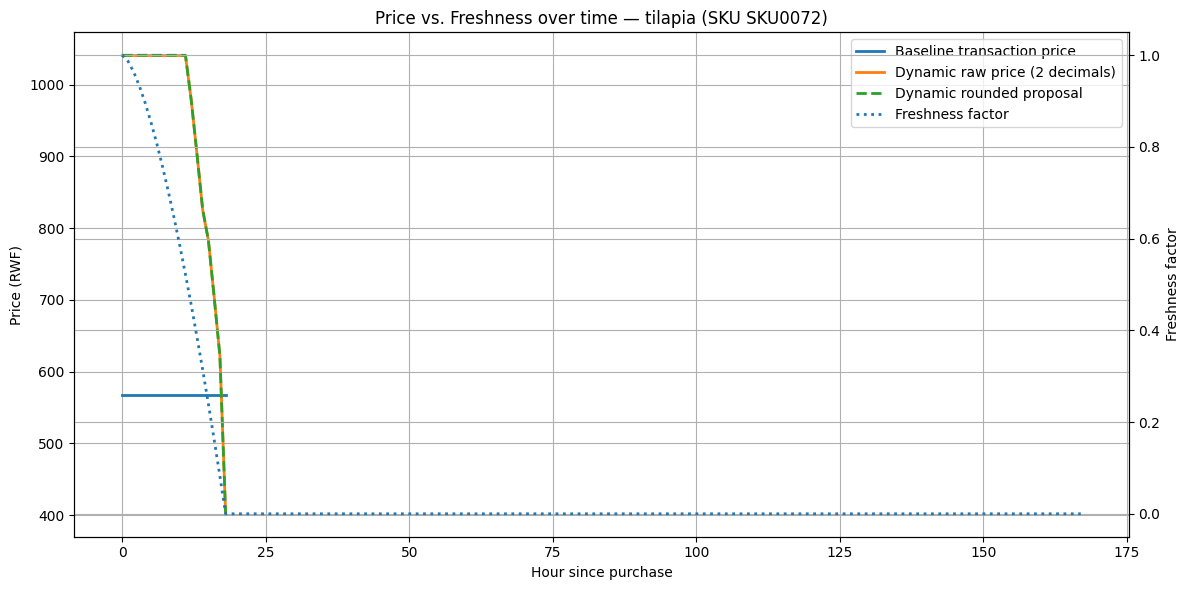

In [77]:
baseline_trace = baseline_run.trace.copy()
dynamic_trace = dynamic_run.trace.copy()

plot_df = (
    baseline_trace[["hour", "rounded_price", "freshness_factor"]]
    .rename(columns={"rounded_price": "baseline_price"})
    .merge(
        dynamic_trace[["hour", "raw_price", "rounded_price"]],
        on="hour",
        how="outer",
    )
    .sort_values("hour")
    .reset_index(drop=True)
)

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(plot_df["hour"], plot_df["baseline_price"], label="Baseline transaction price", linewidth=2)
ax1.plot(plot_df["hour"], plot_df["raw_price"], label="Dynamic raw price (2 decimals)", linewidth=2)
ax1.plot(plot_df["hour"], plot_df["rounded_price"], label="Dynamic rounded proposal", linewidth=2, linestyle="--")
ax1.set_xlabel("Hour since purchase")
ax1.set_ylabel(f"Price ({CURRENCY_CODE})")
ax1.set_title(f"Price vs. Freshness over time — {trace_product} (SKU {trace_sku_id})")

ax2 = ax1.twinx()
ax2.plot(plot_df["hour"], plot_df["freshness_factor"], label="Freshness factor", linewidth=2, linestyle=":")
ax2.set_ylabel("Freshness factor")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper right")

plt.tight_layout()
plt.show()

## Visualization 2 — Strategy comparison

The first bar chart compares **Total Profit**.  
The second bar chart compares **Total Waste (kg)**.

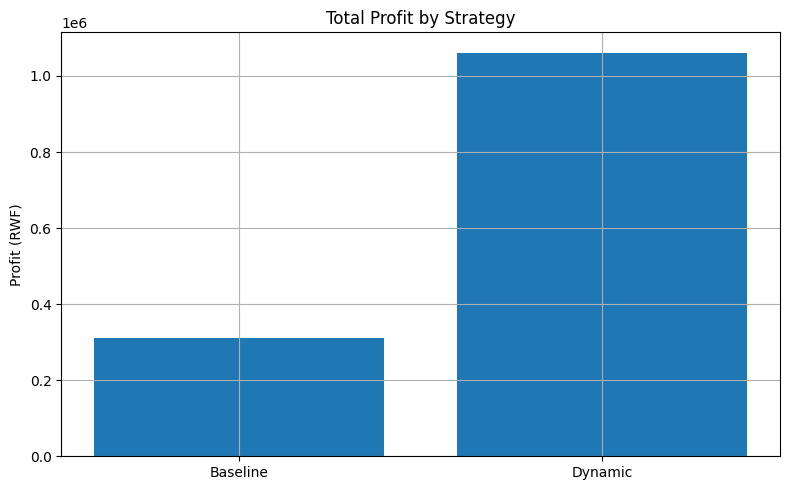

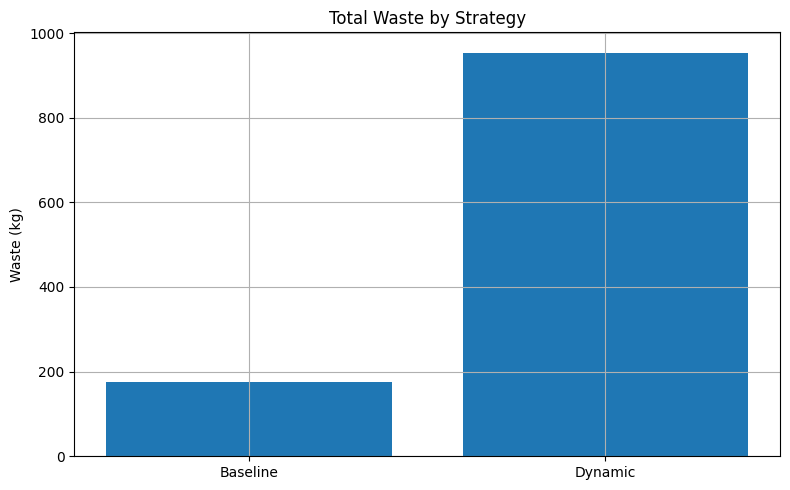

In [78]:
profit_values = [baseline_run.total_profit, dynamic_run.total_profit]
waste_values = [baseline_run.total_waste_kg, dynamic_run.total_waste_kg]
labels = [baseline_run.name, dynamic_run.name]

plt.figure(figsize=(8, 5))
plt.bar(labels, profit_values)
plt.title("Total Profit by Strategy")
plt.ylabel(f"Profit ({CURRENCY_CODE})")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(labels, waste_values)
plt.title("Total Waste by Strategy")
plt.ylabel("Waste (kg)")
plt.tight_layout()
plt.show()

## Conclusion table

This section summarizes the two main business outcomes:
- **Revenue Increase (%)**
- **Waste Reduction (%)**

In [81]:
baseline_revenue = baseline_run.total_revenue
dynamic_revenue = dynamic_run.total_revenue

baseline_waste = baseline_run.total_waste_kg
dynamic_waste = dynamic_run.total_waste_kg

revenue_increase_pct = (
    100.0 * (dynamic_revenue - baseline_revenue) / baseline_revenue
    if baseline_revenue > 0
    else np.nan
)

waste_change_kg = dynamic_waste - baseline_waste

waste_change_pct = (
    100.0 * (dynamic_waste - baseline_waste) / baseline_waste
    if baseline_waste > 0
    else np.nan
)

summary_df = pd.DataFrame(
    [
        {"Metric": "Revenue Increase (%)", "Value": revenue_increase_pct},
        {"Metric": "Baseline Waste (kg)", "Value": baseline_waste},
        {"Metric": "Dynamic Waste (kg)", "Value": dynamic_waste},
        {"Metric": "Waste Change (kg)", "Value": waste_change_kg},
    ]
)

display(summary_df.style.format({"Value": "{:,.2f}"}))

if pd.notna(revenue_increase_pct) and pd.notna(waste_change_pct):
    if revenue_increase_pct > 0 and waste_change_pct < 0:
        print("Conclusion: The dynamic pricing agent generated higher revenue and reduced waste.")
    elif revenue_increase_pct > 0 and waste_change_pct > 0:
        print("Conclusion: The dynamic pricing agent generated higher revenue, but at the cost of increased waste.")
    elif revenue_increase_pct <= 0 and waste_change_pct < 0:
        print("Conclusion: The dynamic pricing agent reduced waste, but revenue did not improve.")
    else:
        print("Conclusion: The dynamic pricing agent did not outperform the baseline and also increased waste.")
else:
    print("Conclusion: One of the percentage metrics could not be computed because the baseline value was zero.")

,Metric,Value
0,Revenue Increase (%),21.59
1,Baseline Waste (kg),176.00
2,Dynamic Waste (kg),954.00
3,Waste Change (kg),778.00


Conclusion: The dynamic pricing agent generated higher revenue, but at the cost of increased waste.
